# Data Science & Analytics – Task 1
## Business Sales Performance Analytics

**Internship:** Future Interns  
**Tools Used:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** Superstore Sales Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
print("Total Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())
print("Total Quantity:", df['Quantity'].sum())

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Quantity: 37873


In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [ ]:
category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(
      by='Sales',
          ascending=False
          )

category_analysis

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


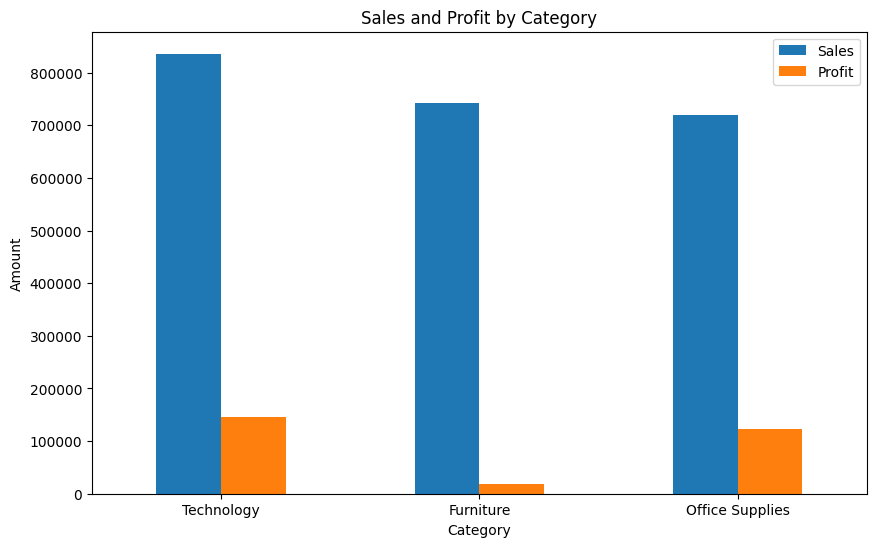

In [ ]:
category_analysis[['Sales', 'Profit']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Sales and Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

In [ ]:
region_analysis = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(
      by='Sales',
          ascending=False
          )

region_analysis

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


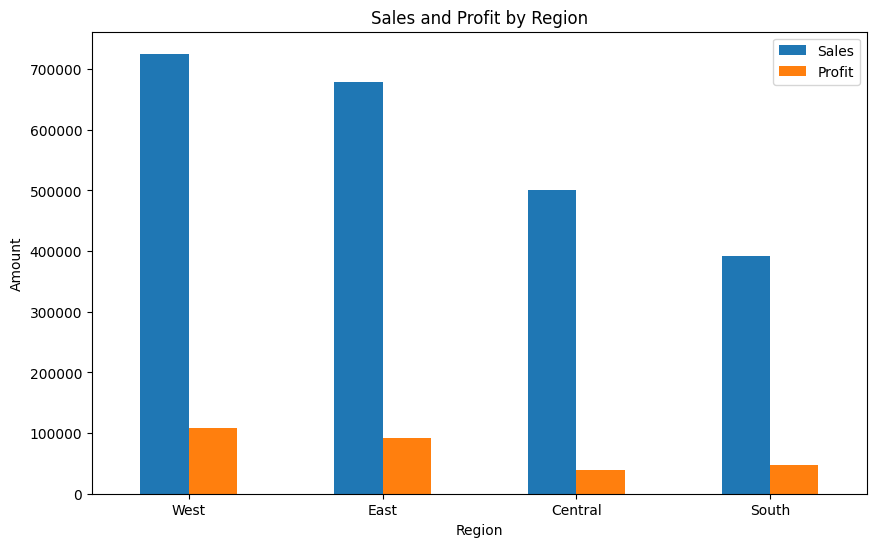

In [ ]:
region_analysis[['Sales', 'Profit']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Sales and Profit by Region')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

In [ ]:
year_analysis = df.groupby(df['Order Date'].dt.year)[['Sales', 'Profit']].sum()

year_analysis

,Sales,Profit
Order Date,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


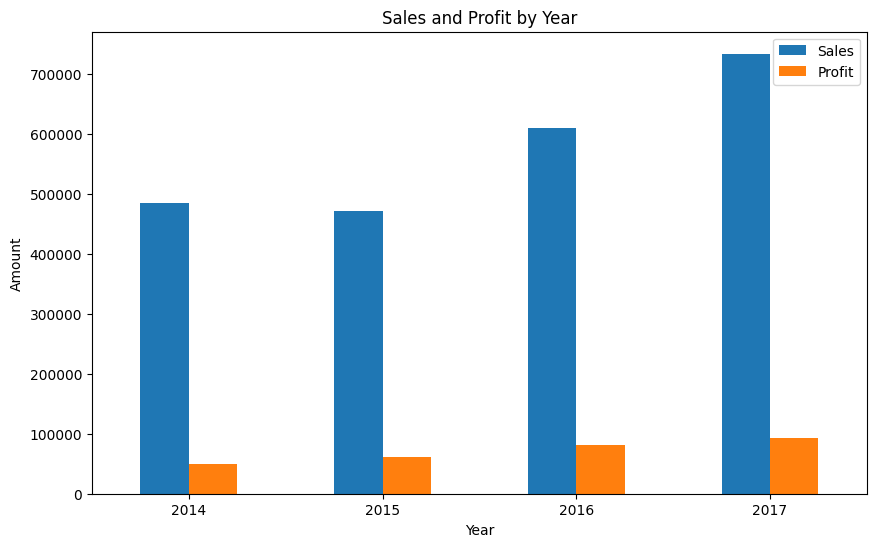

In [ ]:
year_analysis.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Sales and Profit by Year')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

In [ ]:
segment_analysis = df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values(
      by='Sales',
          ascending=False
          )

segment_analysis

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [ ]:
segment_analysis = df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values(
      by='Sales',
          ascending=False
          )

segment_analysis

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


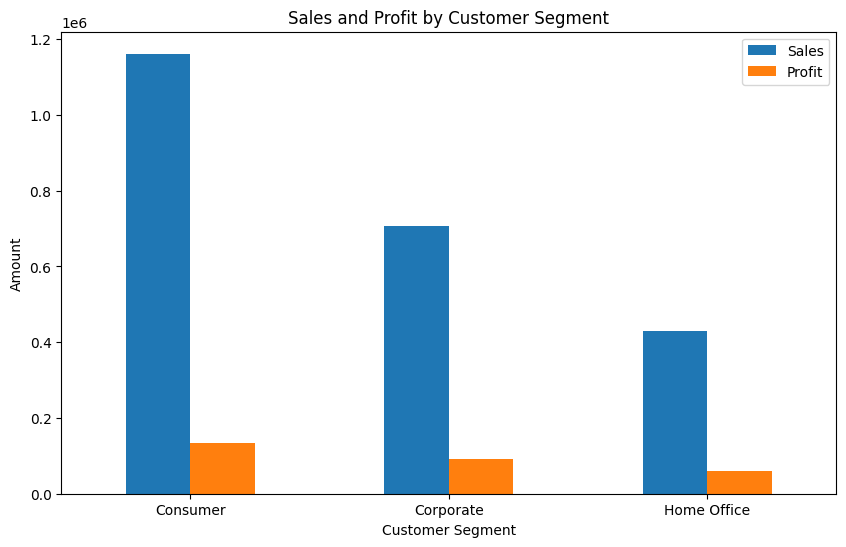

In [ ]:
segment_analysis[['Sales', 'Profit']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Sales and Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

In [ ]:
segment_analysis = df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values(
      by='Sales',
          ascending=False
          )

segment_analysis

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


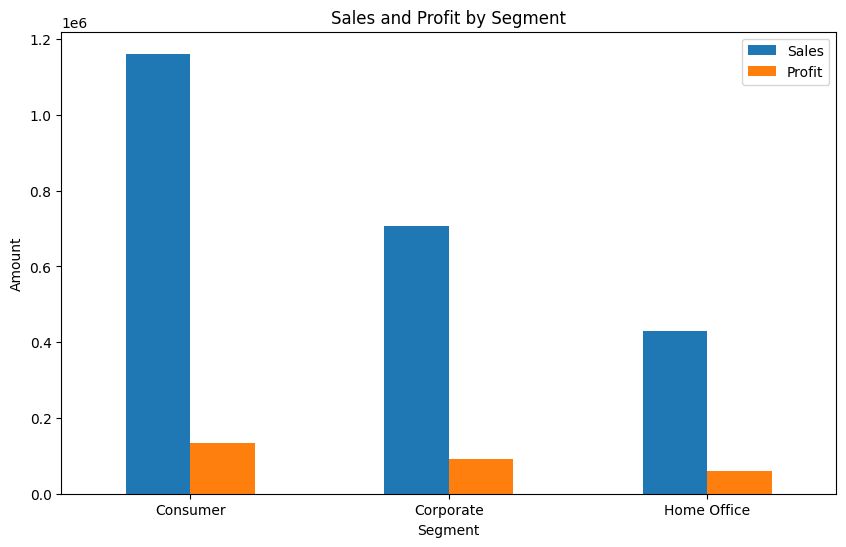

In [ ]:
segment_analysis[['Sales', 'Profit']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Sales and Profit by Segment')
plt.xlabel('Segment')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

In [ ]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(
    ascending=False
).head(10)

top_customers

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


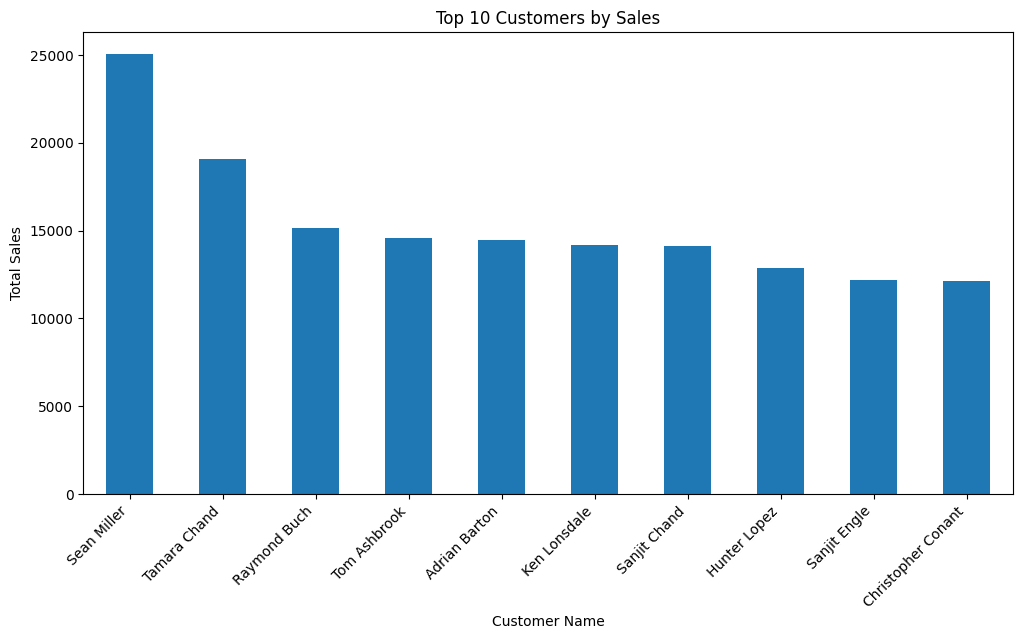

In [ ]:
top_customers.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.head()

,Sales
Order Date,
2014-01,14236.895
2014-02,4519.892
2014-03,55691.009
2014-04,28295.345
2014-05,23648.287


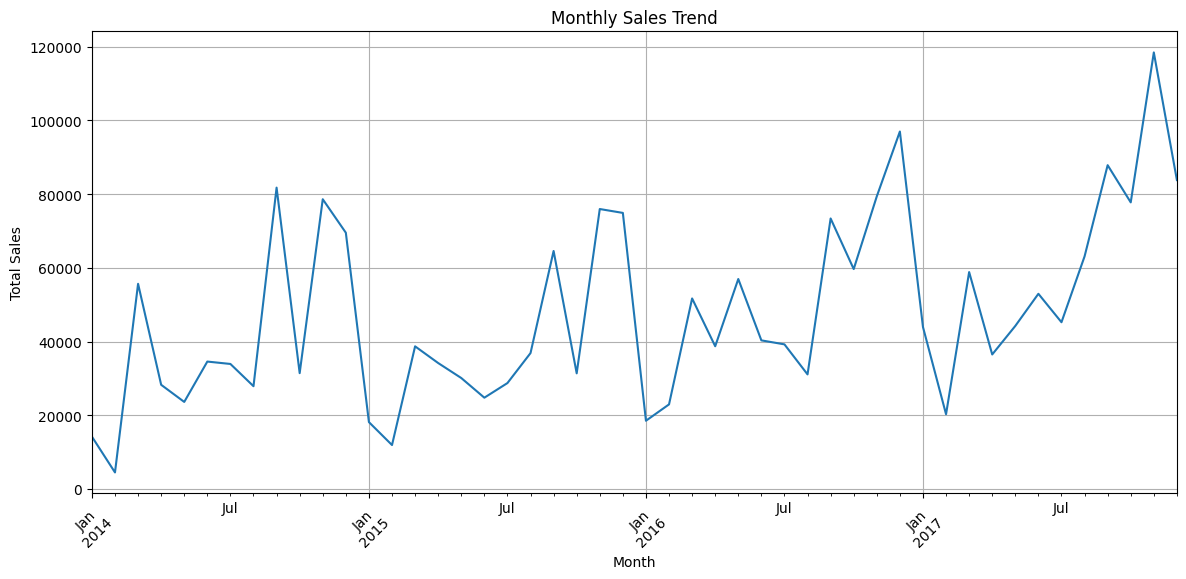

In [ ]:
monthly_sales.plot(
    kind='line',
    figsize=(14, 6)
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
monthly_profit = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Profit'].sum()

monthly_profit.head()

,Profit
Order Date,
2014-01,2450.1907
2014-02,862.3084
2014-03,498.7299
2014-04,3488.8352
2014-05,2738.7096


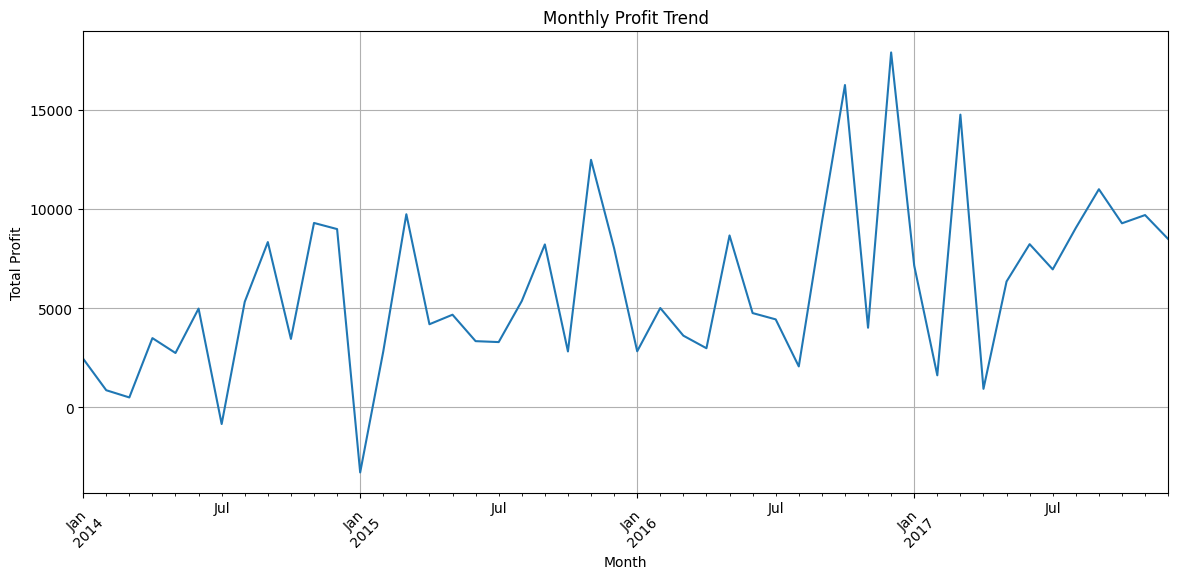

In [ ]:
monthly_profit.plot(
    kind='line',
    figsize=(14, 6)
)

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
comparison = df[['Sales', 'Profit']].sum()

comparison

,0
Sales,2.297201e+06
Profit,2.863970e+05


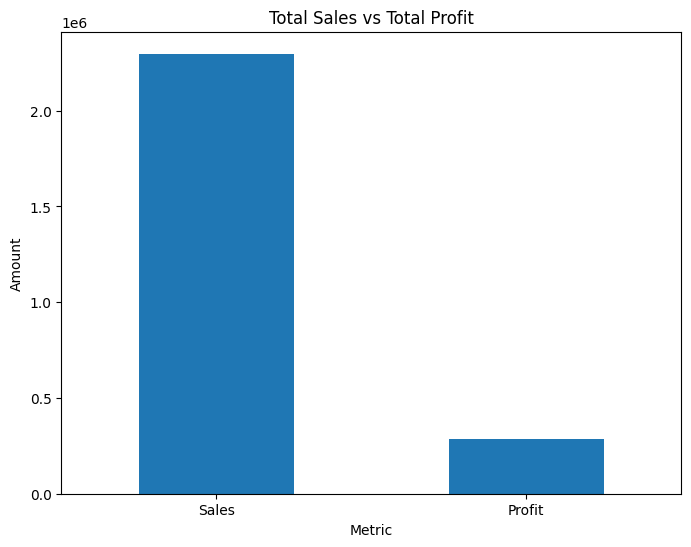

In [ ]:
comparison.plot(
    kind='bar',
    figsize=(8, 6)
)

plt.title('Total Sales vs Total Profit')
plt.xlabel('Metric')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

In [ ]:
discount_analysis = df.groupby('Discount')['Profit'].mean().sort_index()

discount_analysis

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


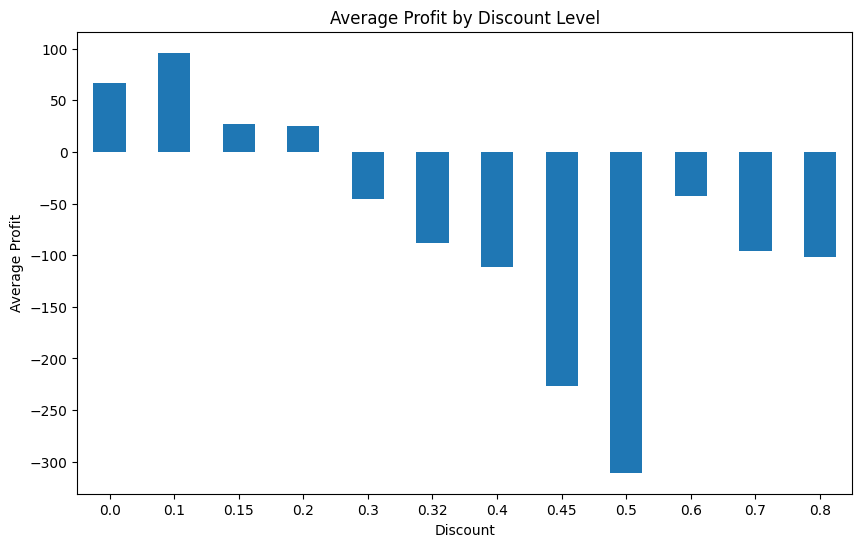

In [ ]:
discount_analysis.plot(kind='bar', figsize=(10, 6)); plt.title('Average Profit by Discount Level'); plt.xlabel('Discount'); plt.ylabel('Average Profit'); plt.xticks(rotation=0); plt.show()

In [ ]:
ship_mode_analysis = df.groupby('Ship Mode')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

ship_mode_analysis

,Sales,Profit
Ship Mode,,
Standard Class,1.358216e+06,164088.7875
Second Class,4.591936e+05,57446.6354
First Class,3.514284e+05,48969.8399
Same Day,1.283631e+05,15891.7589


In [ ]:
discount_analysis.plot(
      kind='bar',
          figsize=(10, 6)
          )

plt.title('Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.xticks(rotation=0)
plt.show()



NameError: name 'discount_analysis' is not defined

In [ ]:
ship_mode_analysis = df.groupby('Ship Mode')[['Sales', 'Profit']].sum().sort_values(
      by='Sales',
          ascending=False
          )

ship_mode_analysis


In [ ]:
ship_mode_analysis = df.groupby('Ship Mode')[['Sales', 'Profit']].sum().sort_values(
      by='Sales',
          ascending=False
          )

ship_mode_analysis


In [ ]:
print("===== BUSINESS SALES PERFORMANCE SUMMARY =====")
print()
print("Total Sales:", round(df['Sales'].sum(), 2))
print("Total Profit:", round(df['Profit'].sum(), 2))
print("Total Quantity:", df['Quantity'].sum())
print()
print("Best Category:", category_analysis['Sales'].idxmax())
print("Best Region:", region_analysis['Sales'].idxmax())
print("Best Customer Segment:", segment_analysis['Sales'].idxmax())
print("Top Product:", top_products.index[0])

In [ ]:
print("KEY BUSINESS INSIGHTS")
print()
print("1. Technology is the highest-performing category based on total sales.")
print("2. West is the strongest region based on total sales.")
print("3. Consumer is the largest customer segment based on total sales.")
print("4. Canon imageCLASS 2200 Advanced Copier is the top-selling product.")
print("5. Higher discount levels can negatively affect average profit.")
print("6. Sales and profit vary significantly across regions and categories.")

In [ ]:
print("BUSINESS RECOMMENDATIONS")
print()
print("1. Increase marketing and inventory focus on Technology products.")
print("2. Study the West region's successful strategies and apply them to weaker regions.")
print("3. Focus customer retention campaigns on the Consumer segment.")
print("4. Maintain strong stock availability for high-performing products.")
print("5. Control excessive discounts to protect profit margins.")
print("6. Monitor monthly sales and profit trends regularly to identify growth opportunities.")

In [ ]:
discount_analysis.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.xticks(rotation=0)

# PNG file save
plt.savefig('average_profit_by_discount.png', dpi=300, bbox_inches='tight')

plt.show()

NameError: name 'discount_analysis' is not defined

In [ ]:
discount_analysis = df.groupby('Discount')['Profit'].mean()

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('YOUR_FILE_NAME.csv')

print(df.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'YOUR_FILE_NAME.csv'

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

# CSV file upload
uploaded = files.upload()

# Uploaded file name automatically get chestundi
filename = list(uploaded.keys())[0]

# Read CSV
df = pd.read_csv(filename)

print("File loaded:", filename)
print("Columns:", df.columns.tolist())

IndexError: list index out of range

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving Sample - Superstore.csv to Sample - Superstore.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Sample - Superstore.csv4')

print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'Sample - Superstore.csv4'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Use the file that was uploaded
filename = list(uploaded.keys())[0]

print("Using file:", filename)

df = pd.read_csv(filename)

print(df.columns.tolist())

Using file: Sample - Superstore.csv


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 2944: invalid start byte

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename, encoding='latin1')

print("File loaded successfully!")
print(df.columns.tolist())

File loaded successfully!
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


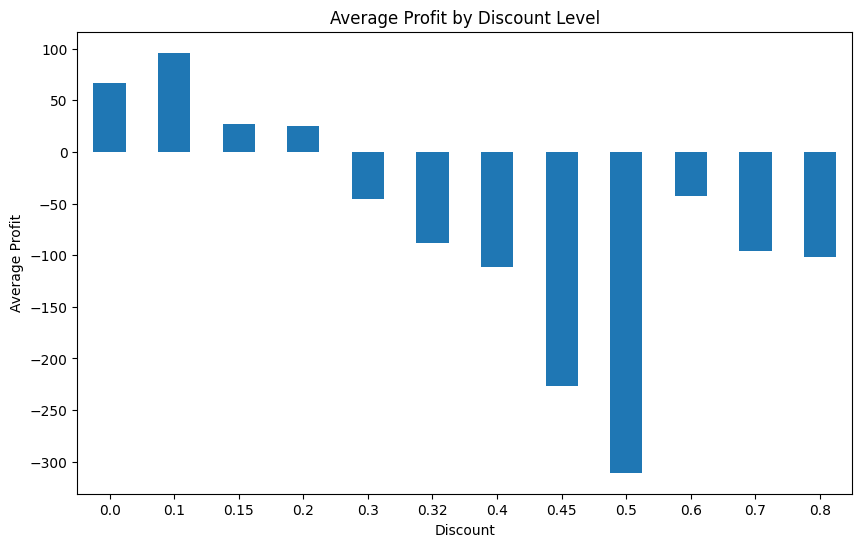

In [ ]:
import matplotlib.pyplot as plt

discount_analysis = df.groupby('Discount')['Profit'].mean()

discount_analysis.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.xticks(rotation=0)

plt.savefig(
    'average_profit_by_discount.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


In [ ]:
from google.colab import files

files.download('average_profit_by_discount.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil
from google.colab import files

# Folder create
os.makedirs('superstore_pngs', exist_ok=True)

# --------------------------------------------------
# 1. CATEGORY - Average Profit
# --------------------------------------------------
category_profit = df.groupby('Category')['Profit'].mean()

plt.figure(figsize=(10, 6))
category_profit.plot(kind='bar')
plt.title('Average Profit by Category')
plt.xlabel('Category')
plt.ylabel('Average Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('superstore_pngs/category_average_profit.png', dpi=300)
plt.close()


# --------------------------------------------------
# 2. REGION - Average Profit
# --------------------------------------------------
region_profit = df.groupby('Region')['Profit'].mean()

plt.figure(figsize=(10, 6))
region_profit.plot(kind='bar')
plt.title('Average Profit by Region')
plt.xlabel('Region')
plt.ylabel('Average Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('superstore_pngs/region_average_profit.png', dpi=300)
plt.close()


# --------------------------------------------------
# 3. DISCOUNT - Average Profit
# --------------------------------------------------
discount_profit = df.groupby('Discount')['Profit'].mean()

plt.figure(figsize=(10, 6))
discount_profit.plot(kind='bar')
plt.title('Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('superstore_pngs/discount_average_profit.png', dpi=300)
plt.close()


# --------------------------------------------------
# 4. MONTHLY - Sales
# --------------------------------------------------
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('superstore_pngs/monthly_sales.png', dpi=300)
plt.close()


# --------------------------------------------------
# 5. MONTHLY - Profit
# --------------------------------------------------
monthly_profit = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Profit'].sum()

plt.figure(figsize=(12, 6))
monthly_profit.plot(kind='line', marker='o')
plt.title('Monthly Profit')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('superstore_pngs/monthly_profit.png', dpi=300)
plt.close()


# --------------------------------------------------
# 6. CATEGORY - Sales
# --------------------------------------------------
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('superstore_pngs/category_total_sales.png', dpi=300)
plt.close()


# --------------------------------------------------
# 7. REGION - Sales
# --------------------------------------------------
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(10, 6))
region_sales.plot(kind='bar')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('superstore_pngs/region_total_sales.png', dpi=300)
plt.close()


# --------------------------------------------------
# 8. SUB-CATEGORY - Profit
# --------------------------------------------------
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(12, 7))
subcategory_profit.plot(kind='barh')
plt.title('Total Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.savefig('superstore_pngs/subcategory_profit.png', dpi=300)
plt.close()


# --------------------------------------------------
# 9. SEGMENT - Profit
# --------------------------------------------------
segment_profit = df.groupby('Segment')['Profit'].sum()

plt.figure(figsize=(10, 6))
segment_profit.plot(kind='bar')
plt.title('Total Profit by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('superstore_pngs/segment_profit.png', dpi=300)
plt.close()


# --------------------------------------------------
# 10. SEGMENT - Sales
# --------------------------------------------------
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(10, 6))
segment_sales.plot(kind='bar')
plt.title('Total Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('superstore_pngs/segment_sales.png', dpi=300)
plt.close()


# --------------------------------------------------
# ZIP ALL PNG FILES
# --------------------------------------------------
shutil.make_archive(
    'superstore_pngs',
    'zip',
    'superstore_pngs'
)

print("✅ All PNG files created successfully!")
print("✅ ZIP file created: superstore_pngs.zip")

# Download ZIP
files.download('superstore_pngs.zip')

✅ All PNG files created successfully!
✅ ZIP file created: superstore_pngs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

The sales analysis shows that Technology is the strongest category and the West region generates the highest sales. The Consumer segment is the largest customer segment, while the Canon imageCLASS 2200 Advanced Copier is the top-selling product.

The analysis also shows that excessive discounts can negatively affect profitability. Based on these findings, the business should focus on high-performing products and categories, strengthen the West region's successful strategies, retain Consumer customers, and control excessive discounting to improve profit margins.